# Intern Performance Prediction
**internee.pk Task — Machine Learning**

Predict whether an intern will successfully complete their program using a Random Forest classifier.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data.csv')
print('Dataset loaded:', df.shape)
df.head()

Dataset loaded: (8558, 17)


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,Current/Intended Major,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date,Unnamed: 16
0,6/14/2023 12:30,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,6/29/2024 18:52,Faria,1/12/2001,Female,Pakistan,Nwihs,Radiology,3/11/2024 12:01,Started,1080,6/14/2023 12:36,11/3/2022 18:30,NaN
1,5/1/2023 5:29,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,6/29/2024 18:52,Poojitha,8/16/2000,Female,India,SAINT LOUIS,Information Systems,3/11/2024 12:01,Started,1080,5/1/2023 6:08,11/3/2022 18:30,NaN
2,4/9/2023 20:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,6/29/2024 18:52,Emmanuel,1/27/2002,Male,United States,Illinois Institute of Technology,Computer Science,3/11/2024 12:01,Started,1080,05/11/2023 1085640:21:29,11/3/2022 18:30,NaN
3,8/29/2023 5:20,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,6/29/2024 18:52,Amrutha Varshini,11/1/1999,Female,United States,Saint Louis University,Information Systems,3/11/2024 12:01,Team Allocated,1070,10/9/2023 22:02,11/3/2022 18:30,NaN
4,1/6/2023 15:26,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,6/29/2024 18:52,Vinay Varshith,4/19/2000,Male,United States,Saint Louis University,Computer Science,3/11/2024 12:01,Started,1080,1/6/2023 15:40,11/3/2022 18:30,NaN


## Step 1 — Clean the Data

In [2]:
# drop empty column
if 'Unnamed: 16' in df.columns:
    df = df.drop(columns=['Unnamed: 16'])

# drop rows with missing status
df = df.dropna(subset=['Status Description'])

# parse dates
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')
df['Apply Date']              = pd.to_datetime(df['Apply Date'], errors='coerce')
df['Date of Birth']           = pd.to_datetime(df['Date of Birth'], errors='coerce')

print('Cleaned! Rows:', len(df))

Cleaned! Rows: 8558


## Step 2 — Create the Target Variable

 define **Success = 1** if the intern was Team Allocated or got a Reward, otherwise **0**.

In [3]:
df['Success'] = df['Status Description'].apply(
    lambda x: 1 if x in ['Team Allocated', 'Rewards Award'] else 0
)

print(df['Success'].value_counts())
print(f'\nSuccess rate: {df["Success"].mean()*100:.1f}%')

Success
0    5253
1    3305
Name: count, dtype: int64

Success rate: 38.6%


## Step 3 — Feature Engineering

- **Age** — calculated from date of birth
- **Days to Apply** — how fast they applied after signing up
- **Gender, Country, Opportunity Category** — encoded as numbers

In [4]:
# age
snapshot = pd.Timestamp('2024-03-11')
df['Age'] = ((snapshot - df['Date of Birth']).dt.days / 365.25).round(0)
df['Age'] = df['Age'].where(df['Age'].between(15, 60))

# days between signup and applying
df['Days to Apply'] = (df['Apply Date'] - df['Learner SignUp DateTime']).dt.days
df['Days to Apply'] = df['Days to Apply'].where(df['Days to Apply'] >= 0)

# encode categorical columns
le = LabelEncoder()
df['Gender_enc']   = le.fit_transform(df['Gender'].fillna('Unknown'))
df['Country_enc']  = le.fit_transform(df['Country'].fillna('Unknown'))
df['Category_enc'] = le.fit_transform(df['Opportunity Category'].fillna('Unknown'))

print('Features created!')
df[['Age', 'Days to Apply', 'Gender_enc', 'Country_enc', 'Category_enc', 'Success']].head()

Features created!


,Age,Days to Apply,Gender_enc,Country_enc,Category_enc,Success
0,23.0,0.0,1,45,1,0
1,24.0,0.0,1,25,1,0
2,22.0,NaN,2,64,1,0
3,24.0,41.0,1,64,1,1
4,24.0,0.0,2,64,1,0


## Step 4 — Train the Model

In [5]:
# select features
features = ['Age', 'Days to Apply', 'Gender_enc', 'Country_enc', 'Category_enc']

# drop rows with any missing feature values
model_df = df[features + ['Success']].dropna()
print('Rows used for training:', len(model_df))

X = model_df[features]
y = model_df['Success']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train random forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Model trained!')

Rows used for training: 7950
Model trained!


## Step 5 — Evaluate the Model

In [6]:
y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 1), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Not Successful', 'Successful']))

Accuracy: 75.5 %

                precision    recall  f1-score   support

Not Successful       0.78      0.85      0.81       976
    Successful       0.71      0.61      0.66       614

      accuracy                           0.76      1590
     macro avg       0.74      0.73      0.73      1590
  weighted avg       0.75      0.76      0.75      1590



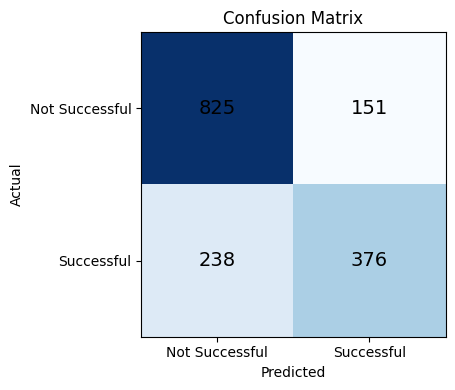

In [7]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Not Successful', 'Successful'])
plt.yticks([0, 1], ['Not Successful', 'Successful'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center', fontsize=14, color='black')
plt.tight_layout()
plt.show()

## Step 6 — Feature Importance


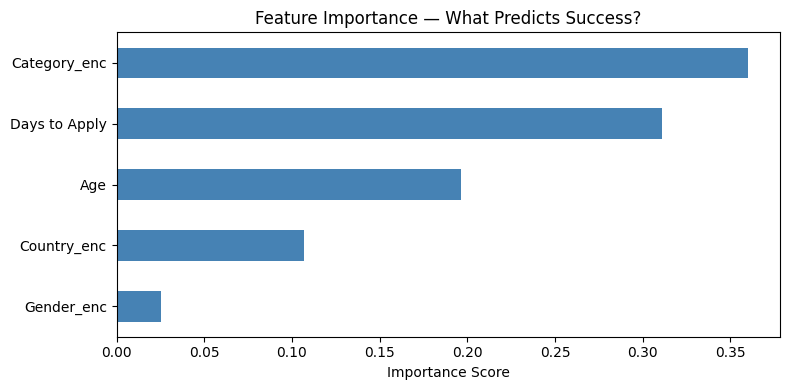

In [8]:
importance = pd.Series(model.feature_importances_, index=features).sort_values()

importance.plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.title('Feature Importance — What Predicts Success?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 7 — Predict on a New Intern

Give the model a hypothetical intern and get a success probability.

In [9]:
# example: 22 year old, applied 3 days after signup, female, from India, doing an Internship
new_intern = pd.DataFrame([{
    'Age': 22,
    'Days to Apply': 3,
    'Gender_enc': 0,    # 0 = Female, 1 = Male (depends on your encoding)
    'Country_enc': 10,  # India's encoded value
    'Category_enc': 2   # Internship's encoded value
}])

prob = model.predict_proba(new_intern)[0][1]
print(f'Success Probability: {prob*100:.1f}%')

if prob >= 0.5:
    print('Prediction: Likely to SUCCEED ✅')
else:
    print('Prediction: At RISK of dropping out ⚠️')

Success Probability: 81.3%
Prediction: Likely to SUCCEED ✅


## Summary

- Used **Random Forest** to predict intern success probability
- Features used: Age, Days to Apply, Gender, Country, Opportunity Category
- The model can help mentors identify at-risk interns early and provide personalized guidance

---

